#  Hypertension Prediction

#### Objective  

This notebook trains and evaluates machine learning models to predict
hypertension using the engineered features created in
`04_Hypertension_Feature_Engineering.ipynb`.

Tasks include:

1. Load engineered features
2. Exploratory Data Analysis
3. Data preprocessing
4. Train multiple machine learning models
5. Hyperparameter tuning
6. Find best model
7. Evaluate model


#### Import libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_validate
)
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

#### Load Dataset

In [2]:
model_df = pd.read_csv("./data/hypertension_features.csv")
model_df.head(3)

,subject_id,gender,age,glucose_mean,glucose_max,glucose_min,creatinine_mean,sodium_mean,systolic_mean,systolic_max,diastolic_mean,diastolic_max,num_admissions,first_admission_year,latest_admission_year,avg_stay_days,num_diagnosis,num_medication,hypertension
0,10014729,0,21,95.315789,140.0,74.0,0.580000,138.000000,100.000000,122.0,45.500000,56.0,2,2013,2013,8.079514,18,75,0
1,10003400,0,72,113.030612,159.0,70.0,1.053333,137.925926,98.127968,142.0,59.662269,109.0,7,2011,2014,11.737004,113,123,1
2,10002428,0,80,108.400000,183.0,67.0,0.598529,135.527027,106.193103,163.0,57.958621,130.0,7,2011,2016,5.621230,84,97,1


In [3]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   subject_id             100 non-null    int64  
 1   gender                 100 non-null    int64  
 2   age                    100 non-null    int64  
 3   glucose_mean           100 non-null    float64
 4   glucose_max            100 non-null    float64
 5   glucose_min            100 non-null    float64
 6   creatinine_mean        100 non-null    float64
 7   sodium_mean            100 non-null    float64
 8   systolic_mean          100 non-null    float64
 9   systolic_max           100 non-null    float64
 10  diastolic_mean         100 non-null    float64
 11  diastolic_max          100 non-null    float64
 12  num_admissions         100 non-null    int64  
 13  first_admission_year   100 non-null    int64  
 14  latest_admission_year  100 non-null    int64  
 15  avg_sta

#### Review EDA

In [4]:
model_df.shape

(100, 19)

Check target balance:

In [5]:
model_df['hypertension'].value_counts()

hypertension
1    53
0    47
Name: count, dtype: int64

Visualization of target:

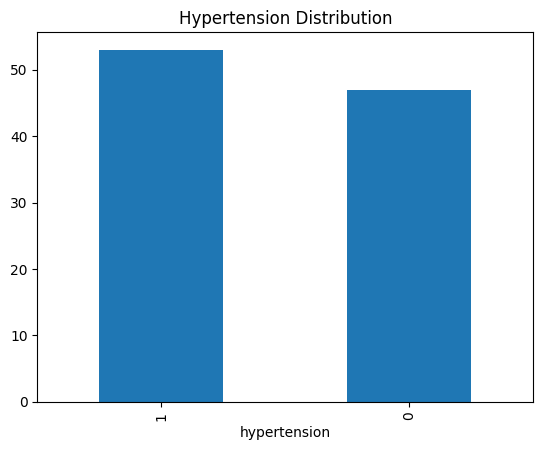

In [6]:
model_df['hypertension'].value_counts().plot(kind='bar')
plt.title('Hypertension Distribution')
plt.show()

#### Split Features and Target

In [7]:
X = model_df.drop(columns=['subject_id', 'hypertension'])
X.head(3)

,gender,age,glucose_mean,glucose_max,glucose_min,creatinine_mean,sodium_mean,systolic_mean,systolic_max,diastolic_mean,diastolic_max,num_admissions,first_admission_year,latest_admission_year,avg_stay_days,num_diagnosis,num_medication
0,0,21,95.315789,140.0,74.0,0.580000,138.000000,100.000000,122.0,45.500000,56.0,2,2013,2013,8.079514,18,75
1,0,72,113.030612,159.0,70.0,1.053333,137.925926,98.127968,142.0,59.662269,109.0,7,2011,2014,11.737004,113,123
2,0,80,108.400000,183.0,67.0,0.598529,135.527027,106.193103,163.0,57.958621,130.0,7,2011,2016,5.621230,84,97


In [8]:
y = model_df['hypertension']
y.head(3)

0    0
1    1
2    1
Name: hypertension, dtype: int64

#### Train/Test Split

In [9]:
random_state = 42

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state, stratify=y)

#### Preprocessing Pipeline

In [11]:
numeric_features = X.columns

In [12]:
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                                      ('scaler', StandardScaler())])

In [13]:
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features)])

#### Logistic Regression

Create model:

In [14]:
logistic = Pipeline(steps=[('preprccessor', preprocessor),
                           ('classifier', LogisticRegression(max_iter=1000, random_state=random_state))])

Train:

In [15]:
logistic.fit(X_train, y_train)

Pipeline(steps=[('preprccessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['gender', 'age', 'glucose_mean', 'glucose_max', 'glucose_min',
       'creatinine_mean', 'sodium_mean', 'systolic_mean', 'systolic_max',
       'diastolic_mean', 'diastolic_max', 'num_admissions',
       'first_admission_year', 'latest_admission_year', 'avg_stay_days',
       'num_diagnosis', 'num_medication'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

Prediction:

In [16]:
y_pred_logistic = logistic.predict(X_test)

Evaluation:

In [17]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.83      0.56      0.67         9
           1       0.71      0.91      0.80        11

    accuracy                           0.75        20
   macro avg       0.77      0.73      0.73        20
weighted avg       0.77      0.75      0.74        20



#### Decision Tree

Build model:

In [18]:
tree = Pipeline(steps=[('preprocessor',preprocessor),('classifier', DecisionTreeClassifier(random_state=random_state))])

Train:

In [19]:
tree.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['gender', 'age', 'glucose_mean', 'glucose_max', 'glucose_min',
       'creatinine_mean', 'sodium_mean', 'systolic_mean', 'systolic_max',
       'diastolic_mean', 'diastolic_max', 'num_admissions',
       'first_admission_year', 'latest_admission_year', 'avg_stay_days',
       'num_diagnosis', 'num_medication'],
      dtype='object'))])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

Prediction:

In [20]:
y_pred_tree = tree.predict(X_test)

Evaluation:

In [21]:
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.55      0.67      0.60         9
           1       0.67      0.55      0.60        11

    accuracy                           0.60        20
   macro avg       0.61      0.61      0.60        20
weighted avg       0.61      0.60      0.60        20



#### Random Forest

Construct model:

In [22]:
rf = Pipeline(steps=[('preprocessor', preprocessor),
                     ('classifier', RandomForestClassifier(n_estimators=300, random_state=random_state))])

Train:

In [23]:
rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['gender', 'age', 'glucose_mean', 'glucose_max', 'glucose_min',
       'creatinine_mean', 'sodium_mean', 'systolic_mean', 'systolic_max',
       'diastolic_mean', 'diastolic_max', 'num_admissions',
       'first_admission_year', 'latest_admission_year', 'avg_stay_days',
       'num_diagnosis', 'num_medication'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

Prediction:

In [24]:
y_pred_rf = rf.predict(X_test)

Evaluation:

In [25]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.71      0.56      0.63         9
           1       0.69      0.82      0.75        11

    accuracy                           0.70        20
   macro avg       0.70      0.69      0.69        20
weighted avg       0.70      0.70      0.69        20



#### Compare Models

In [26]:
models={'Logistic Regression': logistic, 'Decision Tree': tree, 'Random Forest': rf}
scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'}
results = []
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=5, scoring=scoring)
    results.append({'Model': name, 
                    'Accuracy': scores['test_accuracy'].mean(), 
                    'Precision': scores['test_precision'].mean(),
                    'Recall': scores['test_recall'].mean(),
                    'F1 Score': scores['test_f1'].mean(),
                    'ROC-AUC': scores['test_roc_auc'].mean()
                   })
results = pd.DataFrame(results)
results = results.sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True)
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.67,0.684176,0.707273,0.667399,0.748222
1,Random Forest,0.61,0.688312,0.667273,0.626502,0.678697
2,Decision Tree,0.66,0.725397,0.663636,0.680605,0.662929


- Logistic Regression:
  - wins the best accuracy and recall, with the least number of missing patients who have the hypentension condition.
  - has the highest roc-auc value, separating patients with and without hypertension across all possible classification thresholds.
- Decision Tree:
  -  has the fewest false positives based on its highest prediction, as well as its f1 score balancing its precision and recall. 

#### Hyperparameter Tuning

Based on the comparision, Logistic Regression is the strongest model for this dataset, let's tune the model.

In [27]:
param_grid = {'classifier__C': [0.01, 0.1, 1, 10, 100],
             'classifier__penalty': ["l2"],
             'classifier__solver': ["lbfgs"],
             'classifier__class_weight': [None, "balanced"]}

In [28]:
grid = GridSearchCV(estimator=logistic, param_grid=param_grid, scoring='roc_auc', cv=5, n_jobs=-1, refit=True)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprccessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['gender', 'age', 'glucose_mean', 'glucose_max', 'glucose_min',
       'creatinine_mean', 'sodium_mean', 'systolic_mean', 'systolic_max',
       'diastolic_mean', 'diastolic_max'...
       'first_admission_year', 'latest_admission_year', 'avg_stay_days',
       'num_diagnosis', 'num_medication'],
      dtype='object'))])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__class_weight': [None, 'balanced'],
                         'classifier__penalty': ['l2'],
                         'classifier__solver': ['lbfgs']},
             scoring='roc_auc')

Best parameters:

In [29]:
grid.best_params_

{'classifier__C': 0.1,
 'classifier__class_weight': 'balanced',
 'classifier__penalty': 'l2',
 'classifier__solver': 'lbfgs'}

Each best hyperparameter means:  
- classifier__C: 0.1
  - Smaller C means stronger regularization, simpler model, less overfitting
- classifier__class_weight: 'balanced'
  - Adjust weights for imbalance class. Minority one gets higher weight.
- classifier__penalty: 'l2'
  - L2 penalizes large weights, leading to more stable performance
- classifier__solver: 'lbfgs'
  - Generally works well with L2 penalty

These hyperparameters care about the minority class and generalize better, less noisy data.

Best cross-validation score:

In [30]:
print(grid.best_score_)

0.7295634920634921


Use the best model:

In [31]:
best_logistic = grid.best_estimator_
best_logistic

Pipeline(steps=[('preprccessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['gender', 'age', 'glucose_mean', 'glucose_max', 'glucose_min',
       'creatinine_mean', 'sodium_mean', 'systolic_mean', 'systolic_max',
       'diastolic_mean', 'diastolic_max', 'num_admissions',
       'first_admission_year', 'latest_admission_year', 'avg_stay_days',
       'num_diagnosis', 'num_medication'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000, random_state=42))])

Prediction:

In [32]:
y_pred = best_logistic.predict(X_test)
y_prob = best_logistic.predict_proba(X_test)[:,1]

#### Final Evaluation

In [33]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.78      0.82         9
           1       0.83      0.91      0.87        11

    accuracy                           0.85        20
   macro avg       0.85      0.84      0.85        20
weighted avg       0.85      0.85      0.85        20



The recall for class 1 is very high (0.91), meaning the logistic model is catching most of the true hypertension patients.

In [34]:
roc_auc_score(y_test, y_prob)

0.8383838383838383

The logistic model gives a higher predicted probability to the hypertension about 83.8% of the time.

Confusion Matrix:

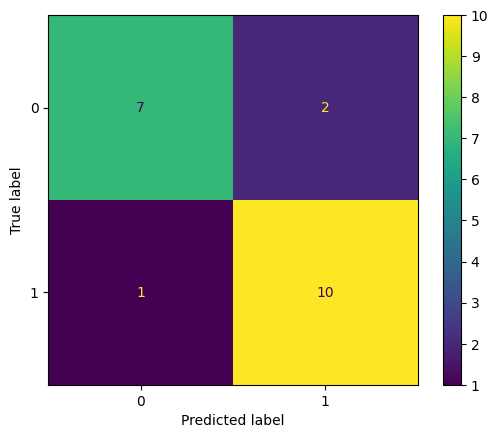

In [35]:
ConfusionMatrixDisplay.from_estimator(best_logistic, X_test, y_test)

The logistic model catches most hypertension, 10 / (10 + 1) = 0.91. It misses one patient with hypertenstion. And it predicts 2 hypertension cases that actually are non-hypertension.

ROC curve:

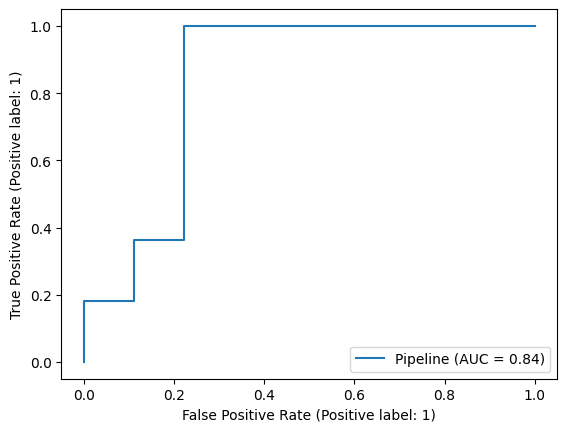

In [36]:
RocCurveDisplay.from_estimator(best_logistic, X_test, y_test)

#### Examine Coefficients

One major advantage of Logistic Regression is that it is interpretable.  

After fitting the best model:

In [37]:
coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': best_logistic.named_steps['classifier'].coef_[0]})
coef['Odds Ratio'] = np.exp(coef['Coefficient'])
coef.sort_values('Odds Ratio', ascending=False)

,Feature,Coefficient,Odds Ratio
1,age,0.538027,1.712624
16,num_medication,0.432967,1.541825
4,glucose_min,0.241323,1.272932
7,systolic_mean,0.234144,1.263827
8,systolic_max,0.069180,1.071629
15,num_diagnosis,0.056771,1.058413
11,num_admissions,0.043432,1.044389
10,diastolic_max,0.040497,1.041328
9,diastolic_mean,0.031303,1.031799
3,glucose_max,0.004876,1.004888


We see that the age, number of medications, glucose and blood pressure features are strongly increasing the odds of hypertension while the average stay days and creatinine mean show negative association.

#### Summary  

We used previously engineered patient hypertension dataset and trained three machine learning models  
- Logistic Regression
- Decision Tree
- Random Forest

Then we evaluated these models and found that the Logistic Regression classifier achieved the best
overall performance based on cross-validation and the scoring features Accuracy, Precision, Recall, F1 Score and ROC-AUC.

Feature importance analysis indicated that age, medications, blood sugar and blood pressure measurements contributed most to the prediction of hypertension.